
### Module 24: Principal Component Analysis (PCA)

This notebook shows PCA **using a library** (scikit-learn) on a **small dataset**, with detailed explanations for each step.

### What you will learn here
You will learn how to:
1. Understand *why* PCA is useful in practice (beyond theory)
2. Prepare data properly (especially **scaling**, which is not optional most of the time)
3. Fit PCA and interpret **explained variance ratio**
4. Choose the number of components using a clear rule (for example, 90% or 95% variance)
5. Transform the dataset into PCA space
6. Visualize the data in 2D using PC1 and PC2
7. Compare model performance **with and without** PCA (small demo)

### Key idea to keep in mind
PCA does **not** select original features. It creates **new features** (principal components) that are combinations of the original ones.



## 1) Imports and Setup

We will use:
- `sklearn.datasets` for a small dataset
- `StandardScaler` for scaling
- `PCA` for dimensionality reduction
- `matplotlib` for plotting

Why scaling?  
PCA is variance-based. If one feature has a larger numeric scale, it can dominate the variance and hijack PCA. Scaling makes features comparable so PCA captures structure, not unit differences.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


## 2) Load a Small Dataset

We will use the **Wine dataset** (classic, small, and perfect for PCA demos):
- 178 samples
- 13 numeric features
- 3 classes

Why this dataset is good for PCA:
- Features are on different scales (some are small decimals, some are larger)
- Many features are correlated
- PCA often produces a nice 2D visualization


In [3]:
data = load_wine()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="class")

X.shape, y.shape

((178, 13), (178,))

In [4]:
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0



## 3) Quick Data Understanding: Feature Scales

Before PCA, always check scales.
If features are on very different ranges, PCA will mainly focus on the largest-scale feature.

Let's look at descriptive stats quickly.


In [5]:
X.describe().T[["mean", "std", "min", "max"]].head(10)

,mean,std,min,max
alcohol,13.000618,0.811827,11.03,14.83
malic_acid,2.336348,1.117146,0.74,5.80
ash,2.366517,0.274344,1.36,3.23
alcalinity_of_ash,19.494944,3.339564,10.60,30.00
magnesium,99.741573,14.282484,70.00,162.00
total_phenols,2.295112,0.625851,0.98,3.88
flavanoids,2.029270,0.998859,0.34,5.08
nonflavanoid_phenols,0.361854,0.124453,0.13,0.66
proanthocyanins,1.590899,0.572359,0.41,3.58
color_intensity,5.058090,2.318286,1.28,13.00



## 4) Scaling (Standardization)

We standardize features using:

z = (x - mean) / std

This makes each feature have:
- mean approximately 0
- standard deviation approximately 1

This is the most common preprocessing step before PCA.


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.51861254, -0.5622498 ,  0.23205254, -1.16959318,  1.91390522,
         0.80899739,  1.03481896, -0.65956311,  1.22488398,  0.25171685,
         0.36217728,  1.84791957,  1.01300893],
       [ 0.24628963, -0.49941338, -0.82799632, -2.49084714,  0.01814502,
         0.56864766,  0.73362894, -0.82071924, -0.54472099, -0.29332133,
         0.40605066,  1.1134493 ,  0.96524152],
       [ 0.19687903,  0.02123125,  1.10933436, -0.2687382 ,  0.08835836,
         0.80899739,  1.21553297, -0.49840699,  2.13596773,  0.26901965,
         0.31830389,  0.78858745,  1.39514818],
       [ 1.69154964, -0.34681064,  0.4879264 , -0.80925118,  0.93091845,
         2.49144552,  1.46652465, -0.98187536,  1.03215473,  1.18606801,
        -0.42754369,  1.18407144,  2.33457383],
       [ 0.29570023,  0.22769377,  1.84040254,  0.45194578,  1.28198515,
         0.80899739,  0.66335127,  0.22679555,  0.40140444, -0.31927553,
         0.36217728,  0.44960118, -0.03787401]])


## 5) Fit PCA (No Component Limit Yet)

First, we fit PCA with all components. This helps us understand:
- how much variance each component explains
- how quickly variance accumulates

Then we decide how many components to keep (for example, enough to explain 90% or 95% variance).


In [7]:
pca_full = PCA()
X_pca_full = pca_full.fit_transform(X_scaled)

explained = pca_full.explained_variance_ratio_
cum_explained = np.cumsum(explained)

explained[:13]

array([0.36198848, 0.1920749 , 0.11123631, 0.0706903 , 0.06563294,
       0.04935823, 0.04238679, 0.02680749, 0.02222153, 0.01930019,
       0.01736836, 0.01298233, 0.00795215])

In [8]:
cum_explained[:10]

array([0.36198848, 0.55406338, 0.66529969, 0.73598999, 0.80162293,
       0.85098116, 0.89336795, 0.92017544, 0.94239698, 0.96169717])


## 6) Explained Variance Plot (Choosing Components)

This plot answers:
- How many components do we need to retain most information?

Common practical rules:
- Keep enough components to explain 90% variance (aggressive reduction)
- Keep enough components to explain 95% variance (safer)

We will compute both thresholds and also visualize cumulative variance.


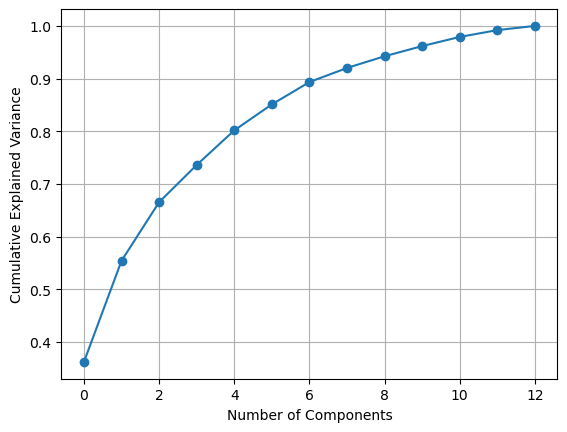

In [9]:
plt.figure()
plt.plot(cum_explained, marker="o")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.grid()
plt.show()

In [10]:
#Selection of k90 and k95
def components_for_threshold(cum_variance,threashold):
  return int(np.argmax(cum_variance>=threashold)+1)

k90 = components_for_threshold(cum_explained, 0.90)
print(k90)

8


In [11]:
k95 = components_for_threshold(cum_explained, 0.95)
print(k95)

10


In [12]:
k97 = components_for_threshold(cum_explained, 0.97)
print(k97)

11


In [13]:
k99 = components_for_threshold(cum_explained, 0.99)
print(k99)

12



Interpretation:
- k90 = minimum number of components to reach at least 90% variance
- k95 = minimum number of components to reach at least 95% variance

We will use k95 for a safer reduction (less information loss).


In [15]:
k = k95
pca = PCA(n_components=k)
X_pca = pca.fit_transform(X_scaled)

X_pca.shape

(178, 10)


## 7) What Are These New Features? (Principal Components)

After PCA transformation:
- Column 1 is PC1
- Column 2 is PC2
- ...
- Column k is PCk

Each PC is a weighted combination of original features.

We can inspect component weights (called loadings):
- A large positive/negative weight means that feature strongly influences that PC.


In [17]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=X.columns,
    columns=[f"PC{i+1}" for i in range(k)]
)

loadings.head(13)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10
alcohol,0.144329,0.483652,-0.207383,-0.017856,-0.265664,0.213539,-0.056396,0.396139,-0.508619,0.211605
malic_acid,-0.245188,0.224931,0.089013,0.536890,0.035214,0.536814,0.420524,0.065827,0.075283,-0.309080
ash,-0.002051,0.316069,0.626224,-0.214176,-0.143025,0.154475,-0.149171,-0.170260,0.307694,-0.027125
alcalinity_of_ash,-0.239320,-0.010591,0.612080,0.060859,0.066103,-0.100825,-0.286969,0.427970,-0.200449,0.052799
magnesium,0.141992,0.299634,0.130757,-0.351797,0.727049,0.038144,0.322883,-0.156361,-0.271403,0.067870
total_phenols,0.394661,0.065040,0.146179,0.198068,-0.149318,-0.084122,-0.027925,-0.405934,-0.286035,-0.320131
flavanoids,0.422934,-0.003360,0.150682,0.152295,-0.109026,-0.018920,-0.060685,-0.187245,-0.049578,-0.163151
nonflavanoid_phenols,-0.298533,0.028779,0.170368,-0.203301,-0.500703,-0.258594,0.595447,-0.233285,-0.195501,0.215535
proanthocyanins,0.313429,0.039302,0.149454,0.399057,0.136860,-0.533795,0.372139,0.368227,0.209145,0.134184
color_intensity,-0.088617,0.529996,-0.137306,0.065926,-0.076437,-0.418644,-0.227712,-0.033797,-0.056218,-0.290775



How to understand loadings:
- Look at PC1: which original features have the biggest absolute weights?
- Those are the features that mainly define the direction of maximum variance.

Let's list the top contributors for PC1 and PC2 (absolute weights).


In [18]:
def top_loadings_for_pc(loadings_df, pc_name, top_n=5):
  s = loadings_df[pc_name].abs().sort_values(ascending=False).head(top_n)
  return pd.DataFrame({"features": s.index, "abs_loadin": s.values})

top_pc1 = top_loadings_for_pc(loadings, "PC1", top_n=5)
top_pc1

,features,abs_loadin
0,flavanoids,0.422934
1,total_phenols,0.394661
2,od280/od315_of_diluted_wines,0.376167
3,proanthocyanins,0.313429
4,nonflavanoid_phenols,0.298533


In [19]:
top_pc2 = top_loadings_for_pc(loadings, "PC2", top_n=5)
top_pc2

,features,abs_loadin
0,color_intensity,0.529996
1,alcohol,0.483652
2,proline,0.364903
3,ash,0.316069
4,magnesium,0.299634



## 8) Visualize the Dataset in 2D Using PC1 and PC2

Even if we keep k95 components for modeling, a very common PCA use case is visualization:
- Take only the first 2 components (PC1 and PC2)
- Plot the points in 2D
- Color points by class label

Important: PCA did not use labels to create PC1/PC2. Labels are only used for visualization.


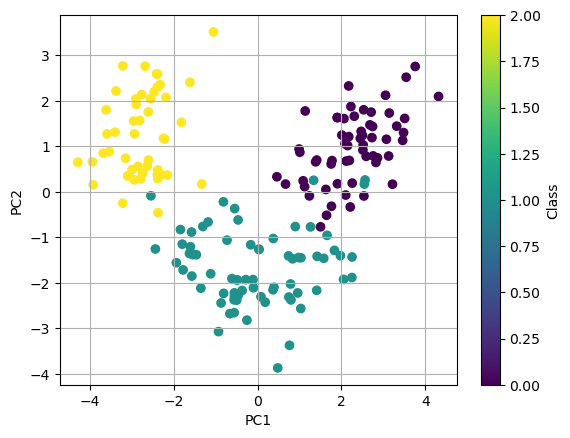

In [20]:
pca2 = PCA(n_components=2)
X_2d = pca2.fit_transform(X_scaled)

plt.figure()
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=y, cmap="viridis")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid()
plt.colorbar(scatter, label="Class")
plt.show()


## 9) PCA for Feature Reduction: Model Demo (With and Without PCA)

Now we do a practical demonstration:
- Train a simple classifier (Logistic Regression) on original scaled features
- Train the same classifier on PCA-reduced features

Important:
PCA is not guaranteed to increase accuracy.
It is mainly used to:
- Reduce dimensions (faster training, simpler representation)
- Remove redundancy/noise
- Help with visualization and stability


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Pipeline WITHOUT PCA: Scale -> Logistic Regression
pipe_no_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_no_pca.fit(X_train, y_train)
pred_no_pca = pipe_no_pca.predict(X_test)

acc_no_pca = accuracy_score(y_test, pred_no_pca)
acc_no_pca

1.0

In [24]:
print("Accuracy (No PCA):", acc_no_pca)
print("\nClassification Report (No PCA):\n")
print(classification_report(y_test, pred_no_pca))

Accuracy (No PCA): 1.0

Classification Report (No PCA):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      1.00      1.00        18
           2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45




### PCA Pipeline

Pipeline WITH PCA:
- Scale
- PCA (keep enough components to preserve 95% variance)
- Logistic Regression

Here, we set `n_components=0.95` which tells sklearn:
"Choose the smallest number of PCs such that explained variance >= 95%."


In [25]:
pipe_with_pca = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(max_iter=500))
])

pipe_with_pca.fit(X_train, y_train)
pred_with_pca = pipe_with_pca.predict(X_test)

acc_with_pca = accuracy_score(y_test, pred_with_pca)
acc_with_pca

0.9777777777777777

In [26]:
print("Accuracy (With PCA):", acc_with_pca)
print("\nClassification Report (With PCA):\n")
print(classification_report(y_test, pred_with_pca))

Accuracy (With PCA): 0.9777777777777777

Classification Report (With PCA):

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.95      1.00      0.97        18
           2       1.00      0.92      0.96        12

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.98        45
weighted avg       0.98      0.98      0.98        45



In [27]:

### Explaination of the Results

If PCA accuracy is similar:
- Great. We reduced dimensions without losing performance.

If PCA accuracy is better:
- PCA likely removed redundancy/noise that was confusing the model.

If PCA accuracy is worse:
- We removed useful information.
- Increase the threshold (for example, 0.98), or skip PCA.

Bottom line:
PCA is a tool. Use it when it matches the problem conditions.


SyntaxError: invalid syntax (3488485378.py, line 3)